# Spark4 Features and Explorations
This notebook proves a few examples of selected features new in Spark 4.x

Run this with Spark 4.0 or higher   
Author Luca.Canali@cern.ch   
First version: Nov 2025

In [1]:
# Start a Spark Session to run the examples
# This uses local mode for simplicity

from pyspark.sql import SparkSession
spark = (SparkSession.builder
         .appName("Test")
         .master("local[*]")
         .config("spark.driver.log.localDir", "/tmp")
         .config("spark.ui.threadDump.flamegraphEnabled", "true")
         .getOrCreate()
        )  

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/03 11:09:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
spark

## Bind variables in SQL (Spark 4.x)  
Introduced in Spark 4.0.0, this feature supports bind variables in SQL queries.# 

In [3]:
spark.sql("execute immediate 'select :text' using('Hello World!' as text)").show()

+------------+
|Hello World!|
+------------+
|Hello World!|
+------------+



## SQL variables (Spark 4.x)

Introduced in Spark 4.0.0, this feature supports variable substitution in SQL queries.

In [4]:
spark.sql("declare mytext='Hello World!'")
spark.sql("select mytext").show()

spark.sql("DECLARE OR REPLACE VARIABLE myvar INT DEFAULT 42;")
spark.sql("select myvar").show()

spark.sql("SET VAR myvar = 12")
spark.sql("select myvar").show()

# Clean up
spark.sql("DROP TEMPORARY VARIABLE myvar")

+------------+
|      mytext|
+------------+
|Hello World!|
+------------+

+-----+
|myvar|
+-----+
|   42|
+-----+

+-----+
|myvar|
+-----+
|   12|
+-----+



DataFrame[]

In [5]:
spark.sql("DECLARE mysqltext STRING")
spark.sql("SET VAR mysqltext = 'select 42'")
spark.sql("execute immediate mysqltext").show()


+---+
| 42|
+---+
| 42|
+---+



## DF Plot
Integrates with plotly to plot dataframe values  
Requires plotly `!pip install plotly` and restart

In [6]:
data = [("A", 10, 1.5), ("B", 30, 2.5), ("C", 20, 3.5)]
columns = ["category", "int_val", "float_val"]
df = spark.createDataFrame(data, columns)

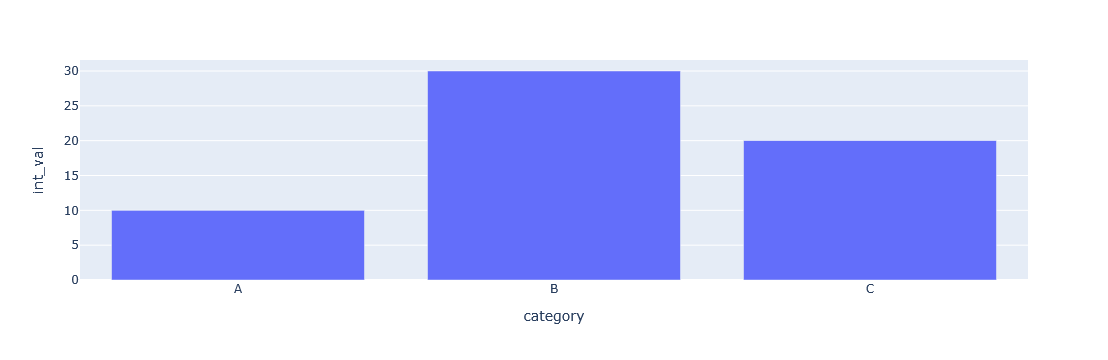

In [7]:
# Requires plotly
# !pip install plotly and restart

df.plot.bar(x="category", y="int_val")  

## SQL functions
Allows to create functions in the catalog and use them in SQL

In [8]:
spark.sql("""
CREATE OR REPLACE FUNCTION testSQL2(id INT) RETURNS TABLE(a INT, b INT)
RETURN SELECT 1, id+1
""")

DataFrame[]

In [9]:
spark.sql("select * from testSQL2(10)").show()

+---+---+
|  a|  b|
+---+---+
|  1| 11|
+---+---+



## Python and SQL
Pyarrow in Pyspark  
User-defined table functions (UDTF)  
Python data source API  

See: https://spark.apache.org/docs/latest/api/python/tutorial/sql/index.html

In [10]:
# Snippet of UDTF from the documenation:
from pyspark.sql.functions import lit, udtf

# Define a UDTF using the `udtf` decorator directly on the class.
@udtf(returnType="num: int, squared: int")
class SquareNumbers:
    def eval(self, start: int, end: int):
        for num in range(start, end + 1):
            yield (num, num * num)

# Invoke the UDTF in PySpark using the SquareNumbers class directly.
SquareNumbers(lit(1), lit(3)).show()

[Stage 11:>                                                                                                                                                                                        (0 + 1) / 1]

+---+-------+
|num|squared|
+---+-------+
|  1|      1|
|  2|      4|
|  3|      9|
+---+-------+



## Variant
Variant is a new datatype introduced in Spark 4.
It's intended to store and operate with semi-structured data in an optimized way (e.g. faster than using JSON).

In [11]:
from datetime import date, datetime
from decimal import Decimal
from pyspark.sql.functions import col
from pyspark.sql.types import StructType, StructField, StringType

from pyspark.sql.functions import try_parse_json, try_variant_get, col

# Sample JSON data
data = [
    '1234567890123456789',
    '12345.6789',
    '"Hello, World!"',
    'true',
    '{"id": 1, "attributes": {"key1": "value1", "key2": "value2"}}',
    '{"id": 2, "attributes": {"key1": "value3", "key2": "value4"}}',
]

# Load data into DataFrame with VARIANT
df = spark.createDataFrame(data, StringType()).select(try_parse_json(col("value")).alias("variant_data"))
df.printSchema()
df.show(truncate=False)


root
 |-- variant_data: variant (nullable = true)

+-------------------------------------------------------+
|variant_data                                           |
+-------------------------------------------------------+
|1234567890123456789                                    |
|12345.6789                                             |
|"Hello, World!"                                        |
|true                                                   |
|{"attributes":{"key1":"value1","key2":"value2"},"id":1}|
|{"attributes":{"key1":"value3","key2":"value4"},"id":2}|
+-------------------------------------------------------+



In [12]:
# Accessing elements inside the VARIANT
df.select(
    try_variant_get(col("variant_data"), "$", "long").alias("long_value"),
    try_variant_get(col("variant_data"), "$.id", "int").alias("id"),
    try_variant_get(col("variant_data"), "$.attributes.key1", "string").alias("key1"),
    try_variant_get(col("variant_data"), "$.attributes.key2", "string").alias("key2"),
).show()


+-------------------+----+------+------+
|         long_value|  id|  key1|  key2|
+-------------------+----+------+------+
|1234567890123456789|NULL|  NULL|  NULL|
|              12345|NULL|  NULL|  NULL|
|               NULL|NULL|  NULL|  NULL|
|                  1|NULL|  NULL|  NULL|
|               NULL|   1|value1|value2|
|               NULL|   2|value3|value4|
+-------------------+----+------+------+



In [13]:
# Collect data and convert to Python objects
[row["variant_data"].toPython() for row in df.collect()]

[1234567890123456789,
 Decimal('12345.6789'),
 'Hello, World!',
 True,
 {'attributes': {'key1': 'value1', 'key2': 'value2'}, 'id': 1},
 {'attributes': {'key1': 'value3', 'key2': 'value4'}, 'id': 2}]

## Profiling UDF
This feature allows profiling Python UDF

In [14]:
import io
from contextlib import redirect_stdout

from pyspark.sql.functions import pandas_udf

df = spark.range(10)
@pandas_udf("long")
def add1(x):
    return x + 1

added = df.select(add1("id"))

spark.conf.set("spark.sql.pyspark.udf.profiler", "perf")
spark.profile.clear()
added.collect()

# Only show top 10 lines
output = io.StringIO()
with redirect_stdout(output):
    spark.profile.show(type="perf")

print("\n".join(output.getvalue().split("\n")[0:20]))

[Stage 19:>                                                                                                                                                                                        (0 + 8) / 8]

Profile of UDF<id=84>
         1642 function calls (1604 primitive calls) in 0.004 seconds

   Ordered by: internal time, cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        8    0.000    0.000    0.002    0.000 series.py:389(__init__)
        8    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        8    0.000    0.000    0.003    0.000 base.py:1380(_arith_method)
        8    0.000    0.000    0.000    0.000 {built-in method _operator.add}
        8    0.000    0.000    0.002    0.000 series.py:6212(_construct_result)
      408    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
        8    0.000    0.000    0.000    0.000 cast.py:1615(maybe_cast_to_integer_array)
        8    0.000    0.000    0.001    0.000 construction.py:517(sanitize_array)
        8    0.000    0.000    0.000    0.000 generic.py:6255(__finalize__)
        8    0.000    0.000    0.000    0.000 array_ops.py:189

In [15]:
added.explain()

== Physical Plan ==
*(2) Project [pythonUDF0#86L AS add1(id)#85L]
+- ArrowEvalPython [add1(id#83L)#84L], [pythonUDF0#86L], 200
   +- *(1) Range (0, 10, step=1, splits=8)




In [16]:
spark.profile.render(id=18, type="perf")  # todo: wender with "flameprof"
spark.profile.show(type="perf")


Profile of UDF<id=84>
         1642 function calls (1604 primitive calls) in 0.004 seconds

   Ordered by: internal time, cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        8    0.000    0.000    0.002    0.000 series.py:389(__init__)
        8    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        8    0.000    0.000    0.003    0.000 base.py:1380(_arith_method)
        8    0.000    0.000    0.000    0.000 {built-in method _operator.add}
        8    0.000    0.000    0.002    0.000 series.py:6212(_construct_result)
      408    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
        8    0.000    0.000    0.000    0.000 cast.py:1615(maybe_cast_to_integer_array)
        8    0.000    0.000    0.001    0.000 construction.py:517(sanitize_array)
        8    0.000    0.000    0.000    0.000 generic.py:6255(__finalize__)
        8    0.000    0.000    0.000    0.000 array_ops.py:189

## SQL pipe syntax
Spark 4 support the SQl pipe syntax, see also: https://spark.apache.org/docs/latest/sql-pipe-syntax.html


In [19]:
# Example from Spark doc

spark.sql("""
VALUES ('apples', 3), ('bananas', 4) t(item, sales)
|> AS produce_sales
|> LEFT JOIN
     (SELECT "apples" AS item, 123 AS id) AS produce_data
     USING (item)
|> SELECT produce_sales.item, sales, id""").show()

+-------+-----+----+
|   item|sales|  id|
+-------+-----+----+
| apples|    3| 123|
|bananas|    4|NULL|
+-------+-----+----+



## Recursive CTE
Spark 4.1 introduces support for recursive common table expressions

In [17]:
spark.sql("""
WITH RECURSIVE t1(n) AS (
    SELECT 1
    UNION ALL
    SELECT n + 1 FROM t1 WHERE n < 5
)
SELECT * from t1""").show()

+---+
|  n|
+---+
|  1|
|  2|
|  3|
|  4|
|  5|
+---+

